In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [27]:
df_US = df[df['job_country'] == 'United States'].copy()

In [28]:
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')

In [29]:
jobs_US_pivot = df_US.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')
jobs_US_pivot.reset_index(inplace=True)

In [30]:
jobs_US_pivot['month_num'] = pd.to_datetime(jobs_US_pivot['job_posted_month'], format='%B').dt.month

In [31]:
jobs_US_pivot.sort_values(by='month_num', inplace=True)

In [32]:
jobs_US_pivot.set_index('job_posted_month', inplace=True)

In [33]:
jobs_US_pivot.drop('month_num', inplace=True, axis=1)

In [34]:
jobs_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [58]:
top_3_jobs = df_US['job_title_short'].value_counts().head(3).index
top_3_jobs = top_3_jobs.tolist()

Text(0.5, 1.0, 'Monthly Postings for Top Data Jobs in the US')

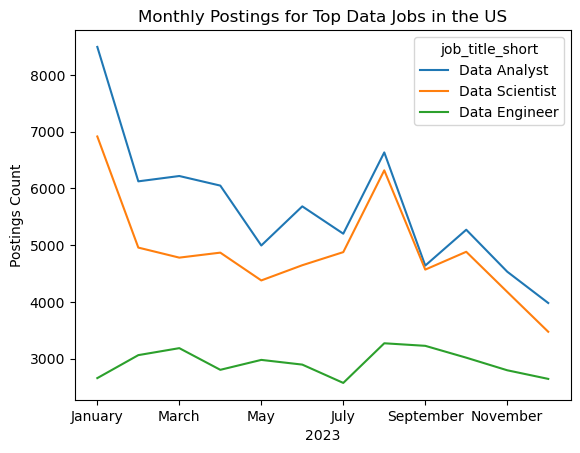

In [63]:
jobs_US_pivot[top_3_jobs].plot(kind='line')
plt.xlabel('2023')
plt.ylabel('Postings Count')
plt.title('Monthly Postings for Top Data Jobs in the US')